In [1]:
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, END
from typing import Annotated
from typing_extensions import TypedDict, Literal
from langgraph.graph.message import add_messages

load_dotenv()

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)  # Groq, cohérent avec le reste du projet
print("✅ LLM prêt (Groq)")

✅ LLM prêt (Groq)


In [2]:
class MedicalState(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    next: Literal["diagnostic_agent", "physician_review", "report_agent", "FINISH"]
    patient_case: str
    question_count: int
    patient_answers: list
    diagnostic_summary: str
    interim_care: str
    physician_treatment: str
    final_report: str

In [3]:
def supervisor(state: MedicalState) -> MedicalState:
    # Décide qui travaille ensuite
    current = state.get("next", "diagnostic_agent")
    
    if current == "diagnostic_agent":
        print("🔀 Supervisor → DiagnosticAgent")
        return {"next": "diagnostic_agent"}
    elif current == "physician_review":
        print("🔀 Supervisor → PhysicianReview")
        return {"next": "physician_review"}
    elif current == "report_agent":
        print("🔀 Supervisor → ReportAgent")
        return {"next": "report_agent"}
    else:
        print("🔀 Supervisor → FIN")
        return {"next": "FINISH"}

def diagnostic_agent(state: MedicalState) -> MedicalState:
    print("🩺 DiagnosticAgent : analyse du cas patient...")
    return {
        "diagnostic_summary": "Syndrome grippal probable.",
        "interim_care": "Repos, hydratation, surveiller la température.",
        "next": "physician_review"
    }

def physician_review(state: MedicalState) -> MedicalState:
    print("👨‍⚕️ PhysicianReview : validation médecin...")
    return {
        "physician_treatment": "Paracétamol 500mg toutes les 6h si fièvre > 38.5°C.",
        "next": "report_agent"
    }

def report_agent(state: MedicalState) -> MedicalState:
    print("📄 ReportAgent : génération du rapport...")
    rapport = f"""
=== RAPPORT CLINIQUE ===
Cas : {state.get('patient_case')}
Synthèse : {state.get('diagnostic_summary')}
Recommandation : {state.get('interim_care')}
Traitement médecin : {state.get('physician_treatment')}
⚠️ Ce système ne remplace pas une consultation médicale.
"""
    return {"final_report": rapport, "next": "FINISH"}

print("✅ Agents définis")

✅ Agents définis


In [4]:
# Construire le graphe
builder = StateGraph(MedicalState)

# Ajouter les noeuds
builder.add_node("supervisor", supervisor)
builder.add_node("diagnostic_agent", diagnostic_agent)
builder.add_node("physician_review", physician_review)
builder.add_node("report_agent", report_agent)

# Définir le point d'entrée
builder.set_entry_point("supervisor")

# Définir les transitions
builder.add_conditional_edges(
    "supervisor",
    lambda s: s.get("next"),
    {
        "diagnostic_agent": "diagnostic_agent",
        "physician_review": "physician_review",
        "report_agent": "report_agent",
        "FINISH": END
    }
)

builder.add_edge("diagnostic_agent", "supervisor")
builder.add_edge("physician_review", "supervisor")
builder.add_edge("report_agent", "supervisor")

graph = builder.compile()
print("✅ Graphe compilé")

✅ Graphe compilé


In [5]:
# Lancer une consultation
result = graph.invoke({
    "patient_case": "Patient de 35 ans, fièvre depuis 2 jours, toux sèche.",
    "question_count": 0,
    "patient_answers": [],
    "next": "diagnostic_agent"
})

print("\n--- RÉSULTAT FINAL ---")
print(result["final_report"])

🔀 Supervisor → DiagnosticAgent
🩺 DiagnosticAgent : analyse du cas patient...
🔀 Supervisor → PhysicianReview
👨‍⚕️ PhysicianReview : validation médecin...
🔀 Supervisor → ReportAgent
📄 ReportAgent : génération du rapport...
🔀 Supervisor → FIN

--- RÉSULTAT FINAL ---

=== RAPPORT CLINIQUE ===
Cas : Patient de 35 ans, fièvre depuis 2 jours, toux sèche.
Synthèse : Syndrome grippal probable.
Recommandation : Repos, hydratation, surveiller la température.
Traitement médecin : Paracétamol 500mg toutes les 6h si fièvre > 38.5°C.
⚠️ Ce système ne remplace pas une consultation médicale.



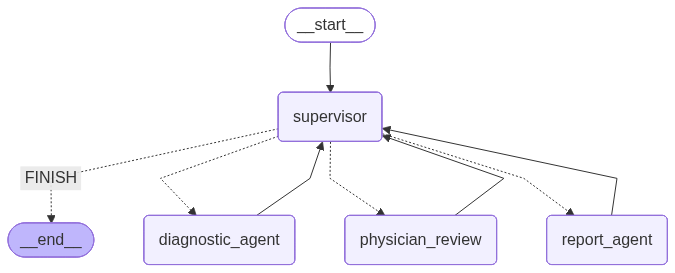

In [6]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, END
from typing import Annotated
from typing_extensions import TypedDict, Literal
from langgraph.graph.message import add_messages

class MedicalState(TypedDict, total=False):
    messages: Annotated[list, add_messages]
    next: Literal["diagnostic_agent", "physician_review", "report_agent", "FINISH"]
    patient_case: str
    question_count: int
    patient_answers: list
    diagnostic_summary: str
    interim_care: str
    physician_treatment: str
    final_report: str

builder = StateGraph(MedicalState)
builder.add_node("supervisor", lambda s: s)
builder.add_node("diagnostic_agent", lambda s: s)
builder.add_node("physician_review", lambda s: s)
builder.add_node("report_agent", lambda s: s)
builder.set_entry_point("supervisor")
builder.add_conditional_edges("supervisor", lambda s: s.get("next"), {
    "diagnostic_agent": "diagnostic_agent",
    "physician_review": "physician_review",
    "report_agent": "report_agent",
    "FINISH": END
})
builder.add_edge("diagnostic_agent", "supervisor")
builder.add_edge("physician_review", "supervisor")
builder.add_edge("report_agent", "supervisor")

graph_viz = builder.compile()
display(Image(graph_viz.get_graph().draw_mermaid_png()))